In [18]:
# Core utilities
import os
import zipfile
import hashlib

# Data handling
import numpy as np
import tqdm
import cv2

# Image processing
from PIL import Image
import imagehash

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# External download
import gdown

## Dependencies & Setup

In [19]:
MAX_SEQ_LEN = 16
FRAME_SIZE = 112

## Download & Extract Dataset

In [20]:
DATA_FILE_ID = "1KCKfyIGbQi8a7bIYta3LM8dFStxVzVX-"
ZIP_NAME = "dataset_bundle.zip"
EXTRACT_DIR = "dataset_root"

download_link = f"https://drive.google.com/uc?id={DATA_FILE_ID}"

gdown.download(download_link, ZIP_NAME, quiet=False)

with zipfile.ZipFile(ZIP_NAME, 'r') as archive:
    archive.extractall(EXTRACT_DIR)

Downloading...
From (original): https://drive.google.com/uc?id=1KCKfyIGbQi8a7bIYta3LM8dFStxVzVX-
From (redirected): https://drive.google.com/uc?id=1KCKfyIGbQi8a7bIYta3LM8dFStxVzVX-&confirm=t&uuid=6c0e4fdd-eff2-4fc0-87a9-41e811c8231f
To: /kaggle/working/dataset_bundle.zip
100%|██████████| 1.78G/1.78G [00:21<00:00, 82.3MB/s]


## Directory Configuration

In [21]:
BASE_DIR = os.path.join(EXTRACT_DIR, "Shop DataSet")

CLASS_A_DIR = os.path.join(BASE_DIR, "non shop lifters")
CLASS_B_DIR = os.path.join(BASE_DIR, "shop lifters")

print("Class A count:", len(os.listdir(CLASS_A_DIR)))
print("Class B count:", len(os.listdir(CLASS_B_DIR)))

Class A count: 531
Class B count: 324


## Duplicate Detection via Hashing

In [22]:
def compute_file_md5(filepath):
    md5 = hashlib.md5()
    with open(filepath, "rb") as f:
        md5.update(f.read())
    return md5.hexdigest()


hash_registry = {}
duplicate_pairs = []

for directory in [CLASS_A_DIR, CLASS_B_DIR]:
    for filename in os.listdir(directory):
        full_path = os.path.join(directory, filename)
        file_hash = compute_file_md5(full_path)

        if file_hash in hash_registry:
            duplicate_pairs.append((full_path, hash_registry[file_hash]))
        else:
            hash_registry[file_hash] = full_path


print("Detected duplicates:")
for dup, orig in duplicate_pairs:
    print(f"Duplicate: {dup}")
    print(f"Original:  {orig}")
    print("-" * 40)

Detected duplicates:
Duplicate: dataset_root/Shop DataSet/non shop lifters/shop_lifter_n_134_1.mp4
Original:  dataset_root/Shop DataSet/non shop lifters/shop_lifter_n_134.mp4
----------------------------------------
Duplicate: dataset_root/Shop DataSet/non shop lifters/shop_lifter_n_64.mp4
Original:  dataset_root/Shop DataSet/non shop lifters/shop_lifter_n_64_1.mp4
----------------------------------------
Duplicate: dataset_root/Shop DataSet/non shop lifters/shop_lifter_n_1.mp4
Original:  dataset_root/Shop DataSet/non shop lifters/shop_lifter_n_1_1.mp4
----------------------------------------
Duplicate: dataset_root/Shop DataSet/non shop lifters/shop_lifter_n_31_1.mp4
Original:  dataset_root/Shop DataSet/non shop lifters/shop_lifter_n_31.mp4
----------------------------------------
Duplicate: dataset_root/Shop DataSet/non shop lifters/shop_lifter_n_56.mp4
Original:  dataset_root/Shop DataSet/non shop lifters/shop_lifter_n_56_1.mp4
----------------------------------------
Duplicate: dat

## Remove Duplicates

In [23]:
for dup_path, _ in duplicate_pairs:
    if os.path.exists(dup_path):
        os.remove(dup_path)

print("Duplicates cleaned")

Duplicates cleaned


## Build Dataset Index

In [24]:
def build_dataset_index():
    paths = []
    labels = []

    for file in os.listdir(CLASS_A_DIR):
        paths.append(os.path.join(CLASS_A_DIR, file))
        labels.append(0)

    for file in os.listdir(CLASS_B_DIR):
        paths.append(os.path.join(CLASS_B_DIR, file))
        labels.append(1)

    return paths, labels


video_files, target_labels = build_dataset_index()

print("Total samples:", len(video_files))

Total samples: 637


## Video Statistics

In [25]:
def analyze_video_lengths(folders):
    frame_counts = []

    for folder in folders:
        for file in os.listdir(folder):
            path = os.path.join(folder, file)
            cap = cv2.VideoCapture(path)

            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            frame_counts.append(total_frames)

            cap.release()

    return frame_counts


frame_lengths = analyze_video_lengths([CLASS_A_DIR, CLASS_B_DIR])

print("Min:", min(frame_lengths))
print("Max:", max(frame_lengths))
print("Avg:", int(np.mean(frame_lengths)))

Min: 75
Max: 1850
Avg: 324


## Frame Sampling Utility

In [26]:
def uniform_frame_sampling(video_path, num_frames=16, target_size=128):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total_frames - 1, num_frames).astype(int)

    sampled_frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()

        if not success:
            continue

        frame = cv2.resize(frame, (target_size, target_size))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        sampled_frames.append(frame)

    cap.release()

    return np.array(sampled_frames) / 255.0

## Train / Val / Test Split

In [27]:
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    video_files,
    target_labels,
    test_size=0.3,
    stratify=target_labels,
    random_state=42
)

X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

## Advanced Frame Extraction + Augmentation

In [28]:
def extract_video_tensor(video_path, augment=False):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames == 0:
        return np.zeros((MAX_SEQ_LEN, FRAME_SIZE, FRAME_SIZE, 3), dtype=np.float32)

    indices = np.linspace(0, total_frames - 1, MAX_SEQ_LEN).astype(int)

    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if not ret:
            frame = np.zeros((FRAME_SIZE, FRAME_SIZE, 3), dtype=np.uint8)
        else:
            frame = cv2.resize(frame, (FRAME_SIZE, FRAME_SIZE))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            if augment:
                if np.random.rand() > 0.5:
                    frame = np.fliplr(frame)

        frames.append(frame)

    cap.release()

    frames = np.array(frames, dtype=np.float32)

    return frames / 255.0

## Video Generator

In [29]:
class VideoDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, paths, labels, batch_size=4, augment=False, shuffle=True, **kwargs):
        super().__init__(**kwargs)  
        self.paths = paths
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
    
        X = np.zeros((len(batch_idx), MAX_SEQ_LEN, FRAME_SIZE, FRAME_SIZE, 3), dtype=np.float32)
        y = np.zeros(len(batch_idx), dtype=np.float32)
    
        for j, i in enumerate(batch_idx):
            X[j] = extract_video_tensor(self.paths[i], self.augment)
            y[j] = self.labels[i]
    
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [30]:
train_gen = VideoDataGenerator(X_train_paths, y_train, batch_size=2, augment=True)

val_gen = VideoDataGenerator(X_val_paths, y_val, batch_size=4, augment=False, shuffle=False)

test_gen = VideoDataGenerator(X_test_paths, y_test, batch_size=4, augment=False, shuffle=False)

## Class Weights

In [31]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_map = dict(enumerate(weights))

## 3D CNN Model (Refactored Architecture)

In [38]:

def build_custom_3d_cnn(input_shape):
    model = models.Sequential(name="Custom3DNet")

    model.add(layers.Input(shape=input_shape))

    # Block 1
    model.add(layers.Conv3D(32, kernel_size=3, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling3D(pool_size=(1,2,2)))

    # Block 2
    model.add(layers.Conv3D(64, kernel_size=3, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling3D(pool_size=(1,2,2)))

    # Block 3
    model.add(layers.Conv3D(128, kernel_size=3, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling3D(pool_size=(2,2,2)))

    # Block 4 (Deep Feature Extraction)
    model.add(layers.Conv3D(128, kernel_size=3, padding='same'))
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.BatchNormalization())

    # Compression
    model.add(layers.GlobalAveragePooling3D())

    # Dense Head
    model.add(layers.Dense(128))
    model.add(layers.LeakyReLU(alpha=0.1))
    model.add(layers.Dropout(0.4))

    model.add(layers.Dense(1, activation='sigmoid'))

    return model


model = build_custom_3d_cnn((MAX_SEQ_LEN, FRAME_SIZE, FRAME_SIZE, 3))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Custom3DNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_8 (Conv3D)               │ (None, 16, 112, 112,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 112, 112,   │             0 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 112, 112,   │           128 │
│ (BatchNormalization)            │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_6 (MaxPooling3D)  │ (None, 16, 56, 56, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_9 (Conv3D)               │ (None, 16, 56, 56, 64) │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 56, 56, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 56, 56, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_7 (MaxPooling3D)  │ (None, 16, 28, 28, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_10 (Conv3D)              │ (None, 16, 28, 28,     │       221,312 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 28, 28,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 28, 28,     │           512 │
│ (BatchNormalization)            │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_8 (MaxPooling3D)  │ (None, 8, 14, 14, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_11 (Conv3D)              │ (None, 8, 14, 14, 128) │       442,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 14, 14, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 14, 14, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling3d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 739,841 (2.82 MB)

 Trainable params: 739,137 (2.82 MB)

 Non-trainable params: 704 (2.75 KB)

## Training Strategy

In [40]:
training_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.4,
        patience=2,
        min_lr=1e-6
    )
]

## Training Loop

In [41]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=training_callbacks,
    class_weight=class_weight_map  
)

Epoch 1/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 341s 1s/step - accuracy: 0.4849 - loss: 0.7041 - val_accuracy: 0.4896 - val_loss: 3.5578 - learning_rate: 2.0000e-04
Epoch 2/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 327s 1s/step - accuracy: 0.6621 - loss: 0.6256 - val_accuracy: 0.4896 - val_loss: 1.6360 - learning_rate: 2.0000e-04
Epoch 3/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 0.7259 - loss: 0.5145 - val_accuracy: 0.4896 - val_loss: 5.5155 - learning_rate: 2.0000e-04
Epoch 4/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 0.7124 - loss: 0.4817 - val_accuracy: 0.4896 - val_loss: 8.7740 - learning_rate: 2.0000e-04
Epoch 5/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - accuracy: 0.8065 - loss: 0.3149 - val_accuracy: 0.4896 - val_loss: 1.3582 - learning_rate: 8.0000e-05
Epoch 6/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - accuracy: 0.7657 - loss: 0.3837 - val_accuracy: 0.9792 - val_loss: 0.2407 - learning_rate: 8.0000e-05
Epoch 7/20
223/223 ━━━━━━━━━━━━━━━━━━━━ 330s 1s/step - acc

## Evaluation

In [42]:
y_pred = model.predict(test_gen)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

24/24 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        49

    accuracy                           1.00        96
   macro avg       1.00      1.00      1.00        96
weighted avg       1.00      1.00      1.00        96



## Training Curves

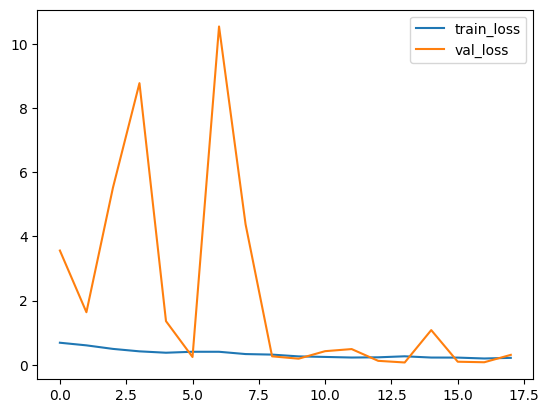

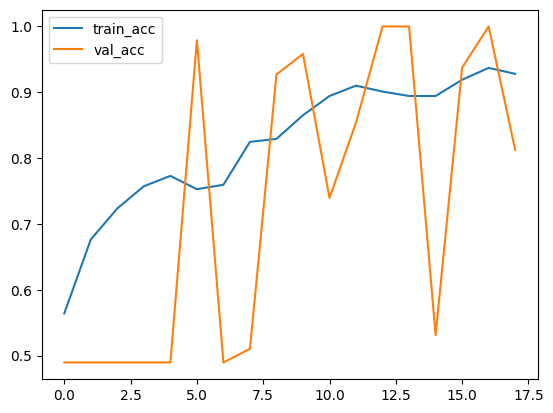

In [43]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

## Confusion Matrix

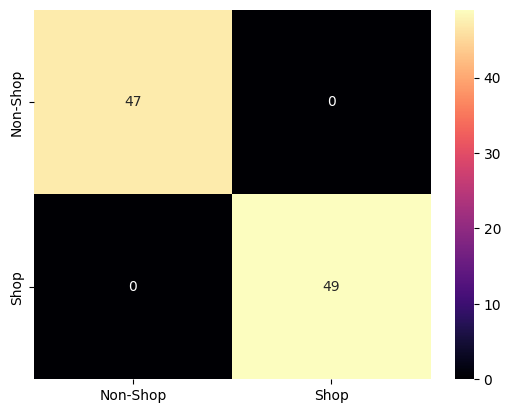

In [44]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='magma',
    xticklabels=['Non-Shop', 'Shop'],
    yticklabels=['Non-Shop', 'Shop']
)

plt.show()

## Save Model

In [45]:
model.save("video_sc_model.h5")